## **Supervised Model III – XGBoost (Improved)**

Key changes from XGBoost_improved:
1. **Normal-only fitting for SVD and unsupervised models** — Previously, Isolation Forest, LOF, Mahalanobis, and SVD were all fitted on the full training set including anomalous users. This diluted their ability to flag outliers because anomalous patterns got baked into the "expected" distribution. Now all four models are fitted exclusively on label==0 users, so anything that deviates from normal behaviour gets a stronger anomaly signal — including unseen anomaly groups the model has never been trained on.

2. **F-beta (β=1.5) replaces F1 as the Optuna objective** — Your precision was already 0.7465 but recall was only 0.4240. Optimising for F1 treats both equally, which lets Optuna trade recall for precision. F-beta with β=1.5 weights recall more heavily, pushing hyperparameter search toward configurations that catch more anomalies. The actual Codabench metric is still F1, but a recall-biased search should find models that perform better on it when unseen groups are present.

3. **Blending XGBoost with a standalone unsupervised score** — XGBoost has zero signal on unseen anomaly types by definition. The new pipeline computes a separate unsupervised anomaly score (averaged IF + LOF + Mahalanobis, all normal-fitted) and blends it with the XGBoost ensemble before calibration: final = 0.80 × XGBoost + 0.20 × unsupervised. This gives unseen-group anomalies a path to cross the 0.5 threshold even when XGBoost scores them low. BLEND_ALPHA is tuneable. The unsupervised scores continue to be added as extra input columns fed to the XGBoost model (added in XGBoost_improved).

Change 2 resulted in lower precision (0.74 --> 0.64), but higher recall (0.42 -> 0.47),
slightly lower AUC overall (0.33 diff), but SLIGHTLY HIGHER F1 (0.5408 --> 0.5463)

In [1]:
results = []

In [ ]:
import matplotlib.pyplot as plt
import zipfile, warnings
import xgboost as xgb
import pandas as pd
import numpy as np
import optuna
from scipy.stats import entropy
from scipy.spatial.distance import mahalanobis
from scipy.sparse import csr_matrix
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, precision_recall_curve
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')

TOTAL_ITEMS = 1000
RATING_RANGE = range(6)
N_SVD_COMPONENTS = 50

#### **Data Loading**

In [3]:
# ── I/O helpers ──────────────────────────────────────────────────────

def load_npz(path: str) -> tuple[pd.DataFrame, pd.DataFrame | None]:
    data = np.load(path)
    XX = pd.DataFrame(data["X"], columns=["user", "item", "rating"])
    yy = None
    if "y" in data:
        yy = pd.DataFrame(data["y"], columns=["user", "label"])
    return XX, yy


def combine_labeled_data(
    *npz_paths: str,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_X, all_y = [], []
    for path in npz_paths:
        data = np.load(path)
        all_X.append(pd.DataFrame(data["X"], columns=["user", "item", "rating"]))
        all_y.append(pd.DataFrame(data["y"], columns=["user", "label"]))

    XX = pd.concat(all_X, ignore_index=True)
    yy = pd.concat(all_y, ignore_index=True).drop_duplicates(subset="user", keep="first")

    n_anom = int(yy["label"].sum())
    print(f"Combined {len(npz_paths)} files")
    print(f"{yy.shape[0]} users ({n_anom} anomalous, {yy.shape[0] - n_anom} normal), {XX.shape[0]} interactions")
    return XX, yy

In [4]:
# ── Sparse matrix builder ────────────────────────────────────────────

def build_user_item_matrix(XX: pd.DataFrame, user_ids: np.ndarray):
    """Build a sparse user×item rating matrix.
    
    Returns:
        mat: sparse CSR matrix (n_users × TOTAL_ITEMS)
        uid_to_row: dict mapping user_id → row index
    """
    uid_to_row = {uid: i for i, uid in enumerate(user_ids)}

    # Vectorised — avoid iterrows on 400k+ rows
    mask = XX["user"].isin(uid_to_row)
    sub = XX.loc[mask]
    rows = sub["user"].map(uid_to_row).values
    cols = sub["item"].values.astype(int)
    vals = sub["rating"].values.astype(float)

    mat = csr_matrix((vals, (rows, cols)), shape=(len(user_ids), TOTAL_ITEMS))
    return mat, uid_to_row

In [5]:
# ── Original hand-crafted features (kept from your notebook) ────────

def compute_item_stats(XX_train: pd.DataFrame) -> dict:
    item_avg = XX_train.groupby("item")["rating"].mean().rename("item_avg_rating")
    item_pop = XX_train.groupby("item")["user"].count().rename("item_popularity")
    return {"item_avg_rating": item_avg, "item_popularity": item_pop}


def build_handcrafted_features(
    XX: pd.DataFrame,
    item_stats: dict,
    total_items: int = TOTAL_ITEMS,
) -> pd.DataFrame:
    """Original 24 features — unchanged from your notebook."""
    item_avg = item_stats["item_avg_rating"]
    item_pop = item_stats["item_popularity"]

    stats = XX.groupby("user")["rating"].agg(
        rating_mean="mean", rating_std="std", rating_median="median",
        rating_min="min", rating_max="max", rating_count="count",
    )
    stats["rating_std"] = stats["rating_std"].fillna(0)
    stats["rating_range"] = stats["rating_max"] - stats["rating_min"]

    rdist = XX.groupby(["user", "rating"]).size().unstack(fill_value=0)
    rdist = rdist.reindex(columns=RATING_RANGE, fill_value=0)
    rprops = rdist.div(rdist.sum(axis=1), axis=0)
    rprops.columns = [f"prop_rating_{i}" for i in RATING_RANGE]
    stats["rating_entropy"] = rprops.apply(
        lambda row: entropy(row.values[row.values > 0]), axis=1
    )
    stats = stats.join(rprops)
    stats["prop_extreme"] = rprops["prop_rating_0"] + rprops["prop_rating_5"]

    stats["unique_items_rated"] = XX.groupby("user")["item"].nunique()
    stats["item_coverage_ratio"] = stats["unique_items_rated"] / total_items

    XX_pop = XX.merge(item_pop, left_on="item", right_index=True, how="left")
    XX_pop["item_popularity"] = XX_pop["item_popularity"].fillna(0)
    pop_f = XX_pop.groupby("user")["item_popularity"].agg(
        avg_item_popularity="mean", std_item_popularity="std",
    )
    pop_f["std_item_popularity"] = pop_f["std_item_popularity"].fillna(0)
    stats = stats.join(pop_f)

    XX_dev = XX.merge(item_avg, left_on="item", right_index=True, how="left")
    global_train_mean = item_avg.mean()
    XX_dev["item_avg_rating"] = XX_dev["item_avg_rating"].fillna(global_train_mean)
    XX_dev["deviation"] = XX_dev["rating"] - XX_dev["item_avg_rating"]
    dev_f = XX_dev.groupby("user")["deviation"].agg(
        mean_deviation="mean", std_deviation="std",
        abs_mean_deviation=lambda x: np.mean(np.abs(x)),
    )
    dev_f["std_deviation"] = dev_f["std_deviation"].fillna(0)
    stats = stats.join(dev_f)

    iqf = XX_dev.groupby("user")["item_avg_rating"].agg(
        avg_item_avg_rating="mean", std_item_avg_rating="std",
    )
    iqf["std_item_avg_rating"] = iqf["std_item_avg_rating"].fillna(0)
    stats = stats.join(iqf)

    return stats.reset_index()

In [ ]:
# ── Structural features ─────────────────────────────────────────

def build_structural_features(XX: pd.DataFrame) -> pd.DataFrame:
    """Features that capture the *shape* of a user's behaviour,
    not just summary statistics.  These generalise across anomaly types."""

    feats = pd.DataFrame({"user": XX["user"].unique()})

    # ── Global rating distribution (for KL divergence) ────────────────
    global_dist = XX["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
    global_dist = np.clip(global_dist, 1e-10, None)  # avoid log(0)

    def user_kl(group):
        user_dist = group["rating"].value_counts(normalize=True).reindex(RATING_RANGE, fill_value=0).values
        user_dist = np.clip(user_dist, 1e-10, None)
        return entropy(user_dist, global_dist)

    kl_df = XX.groupby("user").apply(user_kl).rename("kl_div_from_global")
    feats = feats.merge(kl_df, on="user", how="left")

    # ── Gini coefficient of item selection ────────────────────────────
    def gini_coeff(group):
        counts = group["item"].value_counts().values.astype(float)
        if len(counts) <= 1:
            return 0.0
        counts = np.sort(counts)
        n = len(counts)
        index = np.arange(1, n + 1)
        return (2.0 * np.sum(index * counts) / (n * np.sum(counts))) - (n + 1.0) / n

    gini_df = XX.groupby("user").apply(gini_coeff).rename("item_gini")
    feats = feats.merge(gini_df, on="user", how="left")

    # ── Rating "flatness" — how uniform is the rating vector? ────────
    def rating_flatness(group):
        ratings = group["rating"].values
        if len(ratings) <= 1:
            return 0.0
        # proportion of ratings equal to the mode
        vals, counts = np.unique(ratings, return_counts=True)
        return counts.max() / len(ratings)

    flat_df = XX.groupby("user").apply(rating_flatness).rename("rating_mode_frac")
    feats = feats.merge(flat_df, on="user", how="left")

    # ── Rating skewness & kurtosis ───────────────────────────────────
    skew_df = XX.groupby("user")["rating"].skew().rename("rating_skew").fillna(0)
    kurt_df = XX.groupby("user")["rating"].apply(
        lambda x: x.kurtosis() if len(x) >= 4 else 0.0
    ).rename("rating_kurtosis")
    feats = feats.merge(skew_df, on="user", how="left")
    feats = feats.merge(kurt_df, on="user", how="left")

    # ── Item overlap with popular items ──────────────────────────────
    top_items = set(XX["item"].value_counts().head(100).index)
    def top_item_frac(group):
        user_items = set(group["item"].values)
        return len(user_items & top_items) / max(len(user_items), 1)

    top_df = XX.groupby("user").apply(top_item_frac).rename("frac_top100_items")
    feats = feats.merge(top_df, on="user", how="left")

    # ── Ratings-per-item ratio (detects multi-rating anomalies) ─────
    rpi = XX.groupby("user").apply(
        lambda g: len(g) / g["item"].nunique()
    ).rename("ratings_per_item")
    feats = feats.merge(rpi, on="user", how="left")

    return feats

In [ ]:
# ── SVD reconstruction error (fitted on NORMAL users only) ───––––––──

def build_svd_features(
    XX_ref: pd.DataFrame,
    XX_target: pd.DataFrame,
    target_users: np.ndarray,
    ref_normal_users: np.ndarray | None = None,
    n_components: int = N_SVD_COMPONENTS,
) -> tuple[pd.DataFrame, TruncatedSVD]:
    """Fit SVD on reference data, compute reconstruction error for target users.

    CRITICAL CHANGE: if ref_normal_users is provided, SVD is fitted ONLY on
    those users' interactions.  This means the latent space captures normal
    behaviour only, so anomalous users (including unseen types) reconstruct
    poorly → stronger signal.
    """
    # ── Fit SVD on normal-only reference data ────────────────────────
    if ref_normal_users is not None:
        XX_fit = XX_ref[XX_ref["user"].isin(ref_normal_users)]
    else:
        XX_fit = XX_ref
    fit_users = XX_fit["user"].unique()
    fit_mat, _ = build_user_item_matrix(XX_fit, fit_users)

    n_comp = min(n_components, min(fit_mat.shape) - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    svd.fit(fit_mat)

    # ── Normal-user centroid in latent space ─────────────────────────
    fit_latent = svd.transform(fit_mat)
    centroid = fit_latent.mean(axis=0)

    # ── Compute features for target users ────────────────────────────
    target_mat, _ = build_user_item_matrix(XX_target, target_users)
    latent = svd.transform(target_mat)
    reconstructed = latent @ svd.components_

    target_dense = target_mat.toarray()
    mask = (target_dense != 0).astype(float)
    diff = (target_dense - reconstructed) * mask
    n_rated = np.maximum(np.sum(mask, axis=1), 1)

    feats = pd.DataFrame({
        "user": target_users,
        "svd_recon_mse": np.sum(diff ** 2, axis=1) / n_rated,
        "svd_recon_mae": np.sum(np.abs(diff), axis=1) / n_rated,
        "svd_latent_norm": np.linalg.norm(latent, axis=1),
        "svd_latent_dist_from_centroid": np.linalg.norm(latent - centroid, axis=1),
    })
    return feats, svd


In [ ]:
# ── Unsupervised anomaly scores (fitted on NORMAL users only) ──–––––

def build_unsupervised_scores(
    X_ref: np.ndarray,
    X_target: np.ndarray,
    ref_labels: np.ndarray | None = None,
) -> np.ndarray:
    """Compute unsupervised anomaly scores on X_target.

    If ref_labels is provided, IF/LOF/Mahalanobis are
    fitted ONLY on the normal users (label==0).  This teaches the models
    what 'normal' looks like, so ANY anomaly type — including unseen
    groups — will score as unusual.
    """
    # Use only normal users for fitting
    if ref_labels is not None:
        X_fit = X_ref[ref_labels == 0]
    else:
        X_fit = X_ref

    n_target = X_target.shape[0]
    scores = np.zeros((n_target, 3))

    # ── Isolation Forest ─────────────────────────────────────────────
    iso = IsolationForest(
        n_estimators=300, contamination="auto", random_state=42, n_jobs=-1
    )
    iso.fit(X_fit)
    scores[:, 0] = -iso.score_samples(X_target)

    # ── LOF (novelty detection mode) ─────────────────────────────────
    lof = LocalOutlierFactor(
        n_neighbors=20, contamination="auto", novelty=True, n_jobs=-1
    )
    lof.fit(X_fit)
    scores[:, 1] = -lof.score_samples(X_target)

    # ── Mahalanobis distance from normal centroid ─────────────────────
    try:
        mu = X_fit.mean(axis=0)
        cov = np.cov(X_fit, rowvar=False)
        cov += np.eye(cov.shape[0]) * 1e-6
        cov_inv = np.linalg.inv(cov)
        scores[:, 2] = np.array([
            mahalanobis(x, mu, cov_inv) for x in X_target
        ])
    except Exception:
        mu = X_fit.mean(axis=0)
        scores[:, 2] = np.linalg.norm(X_target - mu, axis=1)

    return scores


UNSUP_COLS = ["iso_forest_score", "lof_score", "mahalanobis_dist"]


In [9]:
# ── Combined feature pipeline ────────────────────────────────────────

def build_all_features(
    XX: pd.DataFrame,
    item_stats: dict,
) -> pd.DataFrame:
    """Merge handcrafted + structural features for a set of users.
    SVD and unsupervised scores are added separately (they need ref/target split).
    """
    hc = build_handcrafted_features(XX, item_stats)
    st = build_structural_features(XX)
    merged = hc.merge(st, on="user", how="left")
    return merged

In [ ]:
# ── Fold feature builder (NORMAL-ONLY unsupervised fitting) ─────────

def make_fold_features(XX_raw, yy_raw, train_users, val_users):
    """Build all features for one CV fold, with proper train/val isolation.
    SVD and unsupervised models are fitted on NORMAL training users only.
    """
    XX_tr  = XX_raw[XX_raw["user"].isin(train_users)].copy()
    XX_val = XX_raw[XX_raw["user"].isin(val_users)].copy()
    yy_tr  = yy_raw[yy_raw["user"].isin(train_users)].copy()
    yy_val = yy_raw[yy_raw["user"].isin(val_users)].copy()

    # Identify normal training users for fitting unsupervised models
    normal_train_users = yy_tr[yy_tr["label"] == 0]["user"].values

    # Item stats from train fold only
    item_stats_tr = compute_item_stats(XX_tr)

    # Handcrafted + structural features
    feats_tr  = build_all_features(XX_tr, item_stats_tr).merge(yy_tr, on="user")
    feats_val = build_all_features(XX_val, item_stats_tr).merge(yy_val, on="user")

    # SVD features — fitted on NORMAL train users only
    svd_tr, svd_model = build_svd_features(
        XX_ref=XX_tr, XX_target=XX_tr,
        target_users=feats_tr["user"].values,
        ref_normal_users=normal_train_users,
    )
    svd_val, _ = build_svd_features(
        XX_ref=XX_tr, XX_target=XX_val,
        target_users=feats_val["user"].values,
        ref_normal_users=normal_train_users,
    )
    feats_tr  = feats_tr.merge(svd_tr, on="user", how="left")
    feats_val = feats_val.merge(svd_val, on="user", how="left")

    # Determine feature columns
    feature_cols = [c for c in feats_tr.columns if c not in ["user", "label"]]
    feats_val = feats_val[["user", "label"] + feature_cols]

    # Scale
    scaler_fold = RobustScaler()
    X_tr_s  = scaler_fold.fit_transform(feats_tr[feature_cols].values)
    X_val_s = scaler_fold.transform(feats_val[feature_cols].values)

    # Unsupervised anomaly scores — fitted on NORMAL train users only
    y_tr_labels = feats_tr["label"].values
    unsup_tr  = build_unsupervised_scores(X_tr_s, X_tr_s, ref_labels=y_tr_labels)
    unsup_val = build_unsupervised_scores(X_tr_s, X_val_s, ref_labels=y_tr_labels)

    X_tr_final  = np.hstack([X_tr_s, unsup_tr])
    X_val_final = np.hstack([X_val_s, unsup_val])
    feature_cols_all = feature_cols + UNSUP_COLS

    y_tr  = feats_tr["label"].values
    y_val = feats_val["label"].values

    return (
        X_tr_final, y_tr, X_val_final, y_val,
        item_stats_tr, feature_cols_all, scaler_fold, svd_model,
        normal_train_users,
    )


In [11]:
# ── Evaluation helper ────────────────────────────────────────────────

def codabench_metrics(test_labels, scores, model_name, verbose=False):
    test_labels = np.asarray(test_labels).astype(int)
    scores = np.asarray(scores).astype(float)
    preds = (scores >= 0.5).astype(int)
    metrics = {
        "model": model_name,
        "AUC": roc_auc_score(test_labels, scores),
        "Precision": precision_score(test_labels, preds, zero_division=0),
        "Recall": recall_score(test_labels, preds, zero_division=0),
        "F1": f1_score(test_labels, preds, zero_division=0),
        "threshold": 0.5,
    }
    if verbose:
        print(f"{model_name} (Codabench t=0.5)")
        for k in ["AUC", "Precision", "Recall", "F1"]:
            print(f"# {k+':':12s} {metrics[k]:.4f}")
    return metrics

In [12]:
# Phase 3 data loading
XX_all, yy_all = combine_labeled_data(
    "data/training_batch_with_labels.npz",
    "data/first_batch_with_labels.npz",
    "data/second_batch_with_labels.npz",
)

Combined 3 files
3060 users (260 anomalous, 2800 normal), 479433 interactions


In [13]:
# Build full feature set for Optuna (all training data)
item_stats_full = compute_item_stats(XX_all)
full_train_df = build_all_features(XX_all, item_stats_full).merge(yy_all, on="user")

# Identify normal users
normal_users_all = yy_all[yy_all["label"] == 0]["user"].values

# SVD fitted on NORMAL users only
all_users = full_train_df["user"].values
svd_full_df, svd_full_model = build_svd_features(
    XX_ref=XX_all, XX_target=XX_all, target_users=all_users,
    ref_normal_users=normal_users_all,
)
full_train_df = full_train_df.merge(svd_full_df, on="user", how="left")

feature_cols = [c for c in full_train_df.columns if c not in ["user", "label"]]

X_trainval = full_train_df[feature_cols].values
y_trainval = full_train_df["label"].values

scaler = RobustScaler()
X_trainval_s = scaler.fit_transform(X_trainval)

# Unsupervised scores fitted on NORMAL users only
unsup_full = build_unsupervised_scores(X_trainval_s, X_trainval_s, ref_labels=y_trainval)
X_trainval_s = np.hstack([X_trainval_s, unsup_full])
feature_cols_all = feature_cols + UNSUP_COLS

print(f"Training users: {len(y_trainval)}")
print(f"Features:       {len(feature_cols_all)}")
print(f"Feature names:  {feature_cols_all}")


Training users: 3060
Features:       38
Feature names:  ['rating_mean', 'rating_std', 'rating_median', 'rating_min', 'rating_max', 'rating_count', 'rating_range', 'rating_entropy', 'prop_rating_0', 'prop_rating_1', 'prop_rating_2', 'prop_rating_3', 'prop_rating_4', 'prop_rating_5', 'prop_extreme', 'unique_items_rated', 'item_coverage_ratio', 'avg_item_popularity', 'std_item_popularity', 'mean_deviation', 'std_deviation', 'abs_mean_deviation', 'avg_item_avg_rating', 'std_item_avg_rating', 'kl_div_from_global', 'item_gini', 'rating_mode_frac', 'rating_skew', 'rating_kurtosis', 'frac_top100_items', 'ratings_per_item', 'svd_recon_mse', 'svd_recon_mae', 'svd_latent_norm', 'svd_latent_dist_from_centroid', 'iso_forest_score', 'lof_score', 'mahalanobis_dist']


#### **Optuna Hyperparameter Search (F1-optimised)**

In [14]:
from sklearn.metrics import fbeta_score

spw_global = np.sum(y_trainval == 0) / np.sum(y_trainval == 1)
OPTUNA_BETA = 1.5  # >1 biases toward recall; try 1.5 or 2.0

def objective(trial):
    grow_policy = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

    params = dict(
        n_estimators      = trial.suggest_int("n_estimators", 100, 4000),
        learning_rate     = trial.suggest_float("learning_rate", 0.001, 0.15, log=True),
        subsample         = trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree  = trial.suggest_float("colsample_bytree", 0.4, 1.0),
        colsample_bylevel = trial.suggest_float("colsample_bylevel", 0.4, 1.0),
        colsample_bynode  = trial.suggest_float("colsample_bynode", 0.4, 1.0),
        min_child_weight  = trial.suggest_int("min_child_weight", 1, 10),
        gamma             = trial.suggest_float("gamma", 0.0, 2.0),
        reg_alpha         = trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        max_delta_step    = trial.suggest_int("max_delta_step", 0, 10),
        scale_pos_weight  = trial.suggest_float("scale_pos_weight", spw_global * 0.5, spw_global * 3.0),
        grow_policy       = grow_policy,
    )

    if grow_policy == "lossguide":
        params["max_leaves"] = trial.suggest_int("max_leaves", 16, 512)
    else:
        params["max_depth"] = trial.suggest_int("max_depth", 3, 12)

    # 5-fold CV, optimise for F-beta (recall-biased)
    # NOTE: minor leakage in unsup scores for speed; proper CV below.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=trial.number)
    fold_fbetas = []
    fold_f1s = []
    fold_aucs = []

    for tr_i, val_i in cv.split(X_trainval_s, y_trainval):
        m = xgb.XGBClassifier(
            **params,
            eval_metric="aucpr",
            early_stopping_rounds=50,
            random_state=42,
            n_jobs=-1,
            tree_method="hist",
        )
        m.fit(
            X_trainval_s[tr_i], y_trainval[tr_i],
            eval_set=[(X_trainval_s[val_i], y_trainval[val_i])],
            verbose=False,
        )
        proba = m.predict_proba(X_trainval_s[val_i])[:, 1]
        preds = (proba >= 0.5).astype(int)
        fold_fbetas.append(fbeta_score(y_trainval[val_i], preds, beta=OPTUNA_BETA, zero_division=0))
        fold_f1s.append(f1_score(y_trainval[val_i], preds, zero_division=0))
        fold_aucs.append(roc_auc_score(y_trainval[val_i], proba))

    trial.set_user_attr("mean_auc", np.mean(fold_aucs))
    trial.set_user_attr("mean_f1", np.mean(fold_f1s))
    return np.mean(fold_fbetas)


In [15]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300, show_progress_bar=True)

best_params = study.best_params
print(f"Best CV F-beta({OPTUNA_BETA}): {study.best_value:.4f}")
print(f"Best CV F1:         {study.best_trial.user_attrs['mean_f1']:.4f}")
print(f"Best CV AUC:        {study.best_trial.user_attrs['mean_auc']:.4f}")
print("Best params:", best_params)


[I 2026-03-29 15:12:44,170] A new study created in memory with name: no-name-25407cca-eb17-4650-ac0d-e80e205d6e8a
Best trial: 0. Best value: 0.806824:   0%|          | 1/300 [00:00<04:43,  1.05it/s]

[I 2026-03-29 15:12:45,119] Trial 0 finished with value: 0.8068239077995175 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 1724, 'learning_rate': 0.12940746109081144, 'subsample': 0.9545170149610998, 'colsample_bytree': 0.5747017552305961, 'colsample_bylevel': 0.9070890787819328, 'colsample_bynode': 0.7290345466526357, 'min_child_weight': 7, 'gamma': 1.8587366173954063, 'reg_alpha': 0.0003257742139361564, 'reg_lambda': 0.5344600887461071, 'max_delta_step': 6, 'scale_pos_weight': 9.054621879879756, 'max_depth': 11}. Best is trial 0 with value: 0.8068239077995175.


Best trial: 0. Best value: 0.806824:   1%|          | 2/300 [00:03<08:17,  1.67s/it]

[I 2026-03-29 15:12:47,291] Trial 1 finished with value: 0.2796099514349798 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 1300, 'learning_rate': 0.0028242950997387833, 'subsample': 0.7614371710326249, 'colsample_bytree': 0.9201472921243745, 'colsample_bylevel': 0.4697930673309456, 'colsample_bynode': 0.8311203991171446, 'min_child_weight': 7, 'gamma': 1.5499966814239452, 'reg_alpha': 0.0010361661942585602, 'reg_lambda': 0.0013804685454139722, 'max_delta_step': 4, 'scale_pos_weight': 17.556111953044645, 'max_leaves': 246}. Best is trial 0 with value: 0.8068239077995175.


Best trial: 0. Best value: 0.806824:   1%|          | 3/300 [00:06<13:10,  2.66s/it]

...

[I 2026-03-29 15:25:42,836] Trial 297 finished with value: 0.43195970009454765 and parameters: {'grow_policy': 'lossguide', 'n_estimators': 2619, 'learning_rate': 0.00580320574288673, 'subsample': 0.5499451410648019, 'colsample_bytree': 0.4454686456876746, 'colsample_bylevel': 0.4658396130844223, 'colsample_bynode': 0.7537074122064765, 'min_child_weight': 3, 'gamma': 1.225125015123262, 'reg_alpha': 0.2756440212979854, 'reg_lambda': 0.0016761348790395746, 'max_delta_step': 2, 'scale_pos_weight': 28.856788788411063, 'max_leaves': 123}. Best is trial 247 with value: 0.8227646844702552.


Best trial: 247. Best value: 0.822765: 100%|█████████▉| 299/300 [13:00<00:03,  3.74s/it]

[I 2026-03-29 15:25:44,970] Trial 298 finished with value: 0.7963424675964379 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 2726, 'learning_rate': 0.03420440860910379, 'subsample': 0.5385473305308857, 'colsample_bytree': 0.7013509683120088, 'colsample_bylevel': 0.4163520663880819, 'colsample_bynode': 0.8083442516977082, 'min_child_weight': 1, 'gamma': 1.1869447666704596, 'reg_alpha': 0.6099507553930483, 'reg_lambda': 0.0026698529608303653, 'max_delta_step': 2, 'scale_pos_weight': 12.066587190483812, 'max_depth': 6}. Best is trial 247 with value: 0.8227646844702552.


Best trial: 247. Best value: 0.822765: 100%|██████████| 300/300 [13:03<00:00,  2.61s/it]

[I 2026-03-29 15:25:47,561] Trial 299 finished with value: 0.7127999424821053 and parameters: {'grow_policy': 'depthwise', 'n_estimators': 2546, 'learning_rate': 0.025028295118548375, 'subsample': 0.5205914811212906, 'colsample_bytree': 0.47945038277907415, 'colsample_bylevel': 0.7531002009463188, 'colsample_bynode': 0.7873911477174446, 'min_child_weight': 1, 'gamma': 1.0960381312817853, 'reg_alpha': 0.812604618353157, 'reg_lambda': 0.0021573637328308045, 'max_delta_step': 3, 'scale_pos_weight': 27.842535798551346, 'max_depth': 5}. Best is trial 247 with value: 0.8227646844702552.
Best CV F-beta(1.5): 0.8228
Best CV F1:         0.7945
Best CV AUC:        0.9809
Best params: {'grow_policy': 'depthwise', 'n_estimators': 2600, 'learning_rate': 0.04014605967935179, 'subsample': 0.5334530194447382, 'colsample_bytree': 0.412441203904921, 'colsample_bylevel': 0.5817383694098177, 'colsample_bynode': 0.830325686594777, 'min_child_weight': 2, 'gamma': 1.2606719641396558, 'reg_alpha': 0.927961371

#### **Cross-Validation (5-fold)**

In [16]:
N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_scores = np.zeros(len(y_trainval))
fold_aucs = []
fold_f1s  = []
fold_artifacts = []

for fold, (tr_idx, va_idx) in enumerate(cv.split(full_train_df[feature_cols].values, y_trainval), 1):
    train_users = full_train_df.iloc[tr_idx]["user"].values
    val_users   = full_train_df.iloc[va_idx]["user"].values

    # Build fold-specific features (normal-only unsupervised fitting)
    X_tr, y_tr, X_va, y_va, item_stats_tr, feat_cols_fold, scaler_fold, svd_fold, normal_users_fold = \
        make_fold_features(XX_all, yy_all, train_users, val_users)

    model = xgb.XGBClassifier(
        **best_params,
        eval_metric="auc",
        random_state=42,
        n_jobs=-1,
        tree_method="hist",
    )
    model.fit(X_tr, y_tr, verbose=False)

    p_va = model.predict_proba(X_va)[:, 1]
    oof_scores[va_idx] = p_va

    fold_auc = roc_auc_score(y_va, p_va)
    fold_f1  = f1_score(y_va, (p_va >= 0.5).astype(int), zero_division=0)
    fold_aucs.append(fold_auc)
    fold_f1s.append(fold_f1)

    fold_artifacts.append({
        "model": model,
        "item_stats": item_stats_tr,
        "feature_cols": feat_cols_fold,
        "scaler": scaler_fold,
        "svd": svd_fold,
        "normal_users": normal_users_fold,
    })

    print(f"Fold {fold:02d}  AUC: {fold_auc:.4f}  F1: {fold_f1:.4f}")

print(f"\nMean fold AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print(f"Mean fold F1:  {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"OOF AUC:       {roc_auc_score(y_trainval, oof_scores):.4f}")
print(f"OOF F1:        {f1_score(y_trainval, (oof_scores >= 0.5).astype(int), zero_division=0):.4f}")


Fold 01  AUC: 0.9417  F1: 0.7167
Fold 02  AUC: 0.9736  F1: 0.7304
Fold 03  AUC: 0.9701  F1: 0.7077
Fold 04  AUC: 0.9660  F1: 0.7087
Fold 05  AUC: 0.9608  F1: 0.6667

Mean fold AUC: 0.9625 ± 0.0112
Mean fold F1:  0.7060 ± 0.0213
OOF AUC:       0.9622
OOF F1:        0.7051


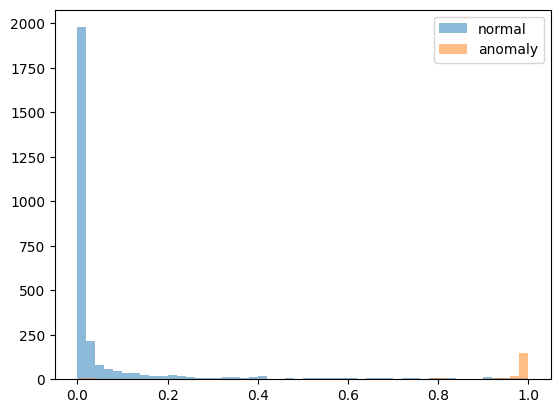

In [23]:
plt.hist(oof_scores[y_trainval==0], bins=50, alpha=0.5, label="normal")
plt.hist(oof_scores[y_trainval==1], bins=50, alpha=0.5, label="anomaly")
plt.legend()

#### **Results Calibration**

In [17]:
calibrator = LogisticRegression(max_iter=1000, random_state=42)
calibrator.fit(oof_scores.reshape(-1, 1), y_trainval)

oof_scores_cal = calibrator.predict_proba(oof_scores.reshape(-1, 1))[:, 1]
print(f"Calibrated OOF AUC: {roc_auc_score(y_trainval, oof_scores_cal):.4f}")
print(f"Calibrated OOF F1:  {f1_score(y_trainval, (oof_scores_cal >= 0.5).astype(int), zero_division=0):.4f}")

Calibrated OOF AUC: 0.9622
Calibrated OOF F1:  0.7634


In [18]:
# Threshold analysis
thresholds = np.linspace(0.01, 0.99, 500)
j_scores, f1_scores_t, prec_list, rec_list = [], [], [], []

for t in thresholds:
    preds_t = (oof_scores_cal >= t).astype(int)
    tp = np.sum((preds_t == 1) & (y_trainval == 1))
    tn = np.sum((preds_t == 0) & (y_trainval == 0))
    fp = np.sum((preds_t == 1) & (y_trainval == 0))
    fn = np.sum((preds_t == 0) & (y_trainval == 1))
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    f1_t = 2 * prec * sens / (prec + sens + 1e-9)
    j_scores.append(sens + spec - 1)
    f1_scores_t.append(f1_t)
    prec_list.append(prec)
    rec_list.append(sens)

best_j_idx  = np.argmax(j_scores)
best_f1_idx = np.argmax(f1_scores_t)

print(f"Optimal threshold — Youden's J : {thresholds[best_j_idx]:.3f}  "
      f"(prec={prec_list[best_j_idx]:.3f}, rec={rec_list[best_j_idx]:.3f})")
print(f"Optimal threshold — Best F1   : {thresholds[best_f1_idx]:.3f}  "
      f"(prec={prec_list[best_f1_idx]:.3f}, rec={rec_list[best_f1_idx]:.3f})")

Optimal threshold — Youden's J : 0.067  (prec=0.527, rec=0.888)
Optimal threshold — Best F1   : 0.468  (prec=0.753, rec=0.785)


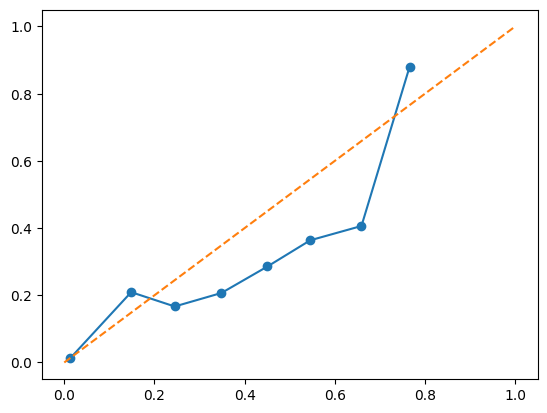

In [28]:
prob_true, prob_pred = calibration_curve(y_trainval, oof_scores_cal, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], '--')

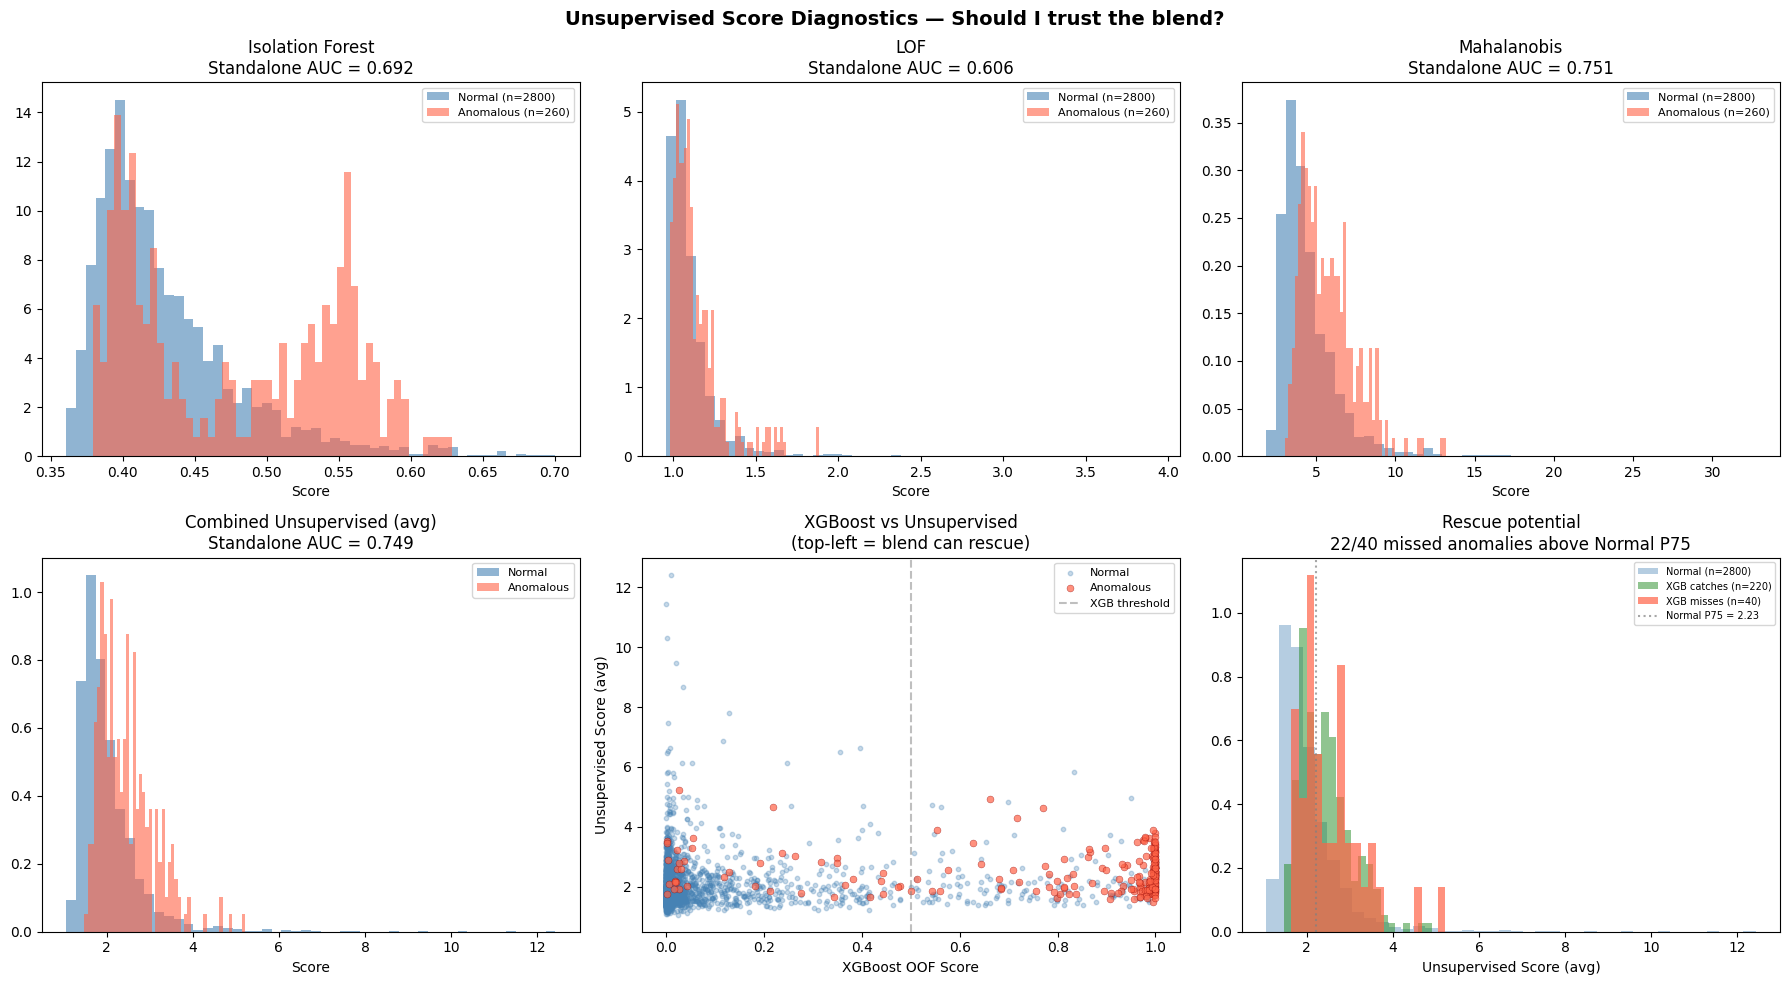


── Decision Guide ──────────────────────────────────────────
Combined unsupervised AUC (standalone): 0.749
XGBoost OOF AUC:                        0.962
Anomalies XGBoost misses (OOF < 0.5):   40/260
  └─ of those, above Normal P75:         22/40

→ Weak unsupervised signal. Keep BLEND_ALPHA = 0.10–0.15 or disable blending.


In [29]:
# ── Unsupervised Score Diagnostics ────────────────────────────────────
# Uses X_trainval_s (last 3 cols = unsup scores), y_trainval, oof_scores.


# Extract the 3 unsupervised score columns from the full feature matrix
unsup_matrix = X_trainval_s[:, -3:]  # [iso_forest, lof, mahalanobis]
unsup_avg = unsup_matrix.mean(axis=1)  # combined score

labels_bool = y_trainval.astype(bool)
normal_mask = ~labels_bool
anom_mask   = labels_bool

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Unsupervised Score Diagnostics — Should I trust the blend?", fontsize=14, fontweight="bold")

# ── Row 1: Score distributions (normal vs anomalous) ────────────────
score_names = ["Isolation Forest", "LOF", "Mahalanobis"]
for i, (ax, name) in enumerate(zip(axes[0], score_names)):
    vals_n = unsup_matrix[normal_mask, i]
    vals_a = unsup_matrix[anom_mask, i]
    ax.hist(vals_n, bins=50, alpha=0.6, label=f"Normal (n={normal_mask.sum()})", density=True, color="steelblue")
    ax.hist(vals_a, bins=50, alpha=0.6, label=f"Anomalous (n={anom_mask.sum()})", density=True, color="tomato")
    auc_i = roc_auc_score(y_trainval, unsup_matrix[:, i])
    ax.set_title(f"{name}\nStandalone AUC = {auc_i:.3f}")
    ax.legend(fontsize=8)
    ax.set_xlabel("Score")

# ── Row 2, Left: Combined unsupervised distribution ────────────────
ax = axes[1][0]
ax.hist(unsup_avg[normal_mask], bins=50, alpha=0.6, label="Normal", density=True, color="steelblue")
ax.hist(unsup_avg[anom_mask], bins=50, alpha=0.6, label="Anomalous", density=True, color="tomato")
auc_combined = roc_auc_score(y_trainval, unsup_avg)
ax.set_title(f"Combined Unsupervised (avg)\nStandalone AUC = {auc_combined:.3f}")
ax.legend(fontsize=8)
ax.set_xlabel("Score")

# ── Row 2, Middle: XGBoost OOF vs Unsupervised scatter ─────────────
ax = axes[1][1]
ax.scatter(oof_scores[normal_mask], unsup_avg[normal_mask],
           alpha=0.3, s=10, c="steelblue", label="Normal")
ax.scatter(oof_scores[anom_mask], unsup_avg[anom_mask],
           alpha=0.7, s=25, c="tomato", label="Anomalous", edgecolors="darkred", linewidths=0.3)
ax.axvline(0.5, color="gray", ls="--", alpha=0.5, label="XGB threshold")
ax.set_xlabel("XGBoost OOF Score")
ax.set_ylabel("Unsupervised Score (avg)")
ax.set_title("XGBoost vs Unsupervised\n(top-left = blend can rescue)")
ax.legend(fontsize=8)

# ── Row 2, Right: Rescue analysis ─────────────────────────────────
# How many anomalies does XGBoost miss (OOF < 0.5) that unsupervised catches?
ax = axes[1][2]
xgb_missed = anom_mask & (oof_scores < 0.5)  # anomalies XGBoost misses
xgb_caught = anom_mask & (oof_scores >= 0.5)  # anomalies XGBoost catches
n_missed = xgb_missed.sum()
n_caught = xgb_caught.sum()

if n_missed > 0:
    unsup_missed = unsup_avg[xgb_missed]
    unsup_caught = unsup_avg[xgb_caught]
    unsup_normal = unsup_avg[normal_mask]
    
    ax.hist(unsup_normal, bins=40, alpha=0.4, label=f"Normal (n={normal_mask.sum()})",
            density=True, color="steelblue")
    ax.hist(unsup_caught, bins=20, alpha=0.5, label=f"XGB catches (n={n_caught})",
            density=True, color="forestgreen")
    ax.hist(unsup_missed, bins=20, alpha=0.7, label=f"XGB misses (n={n_missed})",
            density=True, color="tomato")
    
    # What fraction of XGB-missed anomalies have high unsupervised scores?
    p75_normal = np.percentile(unsup_normal, 75)
    rescuable = (unsup_missed > p75_normal).sum()
    ax.axvline(p75_normal, color="gray", ls=":", alpha=0.7, label=f"Normal P75 = {p75_normal:.2f}")
    ax.set_title(f"Rescue potential\n{rescuable}/{n_missed} missed anomalies above Normal P75")
else:
    ax.set_title("No missed anomalies (OOF)")
ax.legend(fontsize=7)
ax.set_xlabel("Unsupervised Score (avg)")

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────
print("\n── Decision Guide ──────────────────────────────────────────")
print(f"Combined unsupervised AUC (standalone): {auc_combined:.3f}")
print(f"XGBoost OOF AUC:                        {roc_auc_score(y_trainval, oof_scores):.3f}")
print(f"Anomalies XGBoost misses (OOF < 0.5):   {n_missed}/{anom_mask.sum()}")
if n_missed > 0:
    print(f"  └─ of those, above Normal P75:         {rescuable}/{n_missed}")
print()
if auc_combined > 0.85 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.4:
    print("→ Unsupervised scores separate well AND can rescue missed anomalies.")
    print("  Try BLEND_ALPHA = 0.25–0.35")
elif auc_combined > 0.75 and n_missed > 0 and rescuable / max(n_missed, 1) > 0.2:
    print("→ Moderate signal. Keep BLEND_ALPHA = 0.15–0.25")
else:
    print("→ Weak unsupervised signal. Keep BLEND_ALPHA = 0.10–0.15 or disable blending.")


#### **Model Predictions**

In [19]:
# Load test data
XX_test, _ = load_npz("data/third_batch.npz")

In [20]:
# ── Build NORMAL-ONLY reference for unsupervised scoring ───────────
ref_df = build_all_features(XX_all, item_stats_full)
svd_ref_df, _ = build_svd_features(
    XX_ref=XX_all, XX_target=XX_all, target_users=ref_df["user"].values,
    ref_normal_users=normal_users_all,
)
ref_df = ref_df.merge(svd_ref_df, on="user", how="left")
ref_labels = ref_df.merge(yy_all, on="user", how="left")["label"].values

# ── Ensemble predictions across folds ─────────────────────────────
fold_test_preds = []

for fold_id, art in enumerate(fold_artifacts, 1):
    model           = art["model"]
    item_stats_fold = art["item_stats"]
    feat_cols_fold  = art["feature_cols"]
    scaler_fold     = art["scaler"]

    base_cols = [c for c in feat_cols_fold if c not in UNSUP_COLS]

    # Test features (handcrafted + structural + SVD)
    test_df = build_all_features(XX_test, item_stats_fold)
    svd_test_df, _ = build_svd_features(
        XX_ref=XX_all, XX_target=XX_test,
        target_users=test_df["user"].values,
        ref_normal_users=normal_users_all,
    )
    test_df = test_df.merge(svd_test_df, on="user", how="left")

    for c in base_cols:
        if c not in test_df.columns:
            test_df[c] = 0.0

    X_test_base_s = scaler_fold.transform(test_df[base_cols].values)

    # Unsupervised scores — reference = NORMAL training users only
    X_ref_base_s = scaler_fold.transform(
        ref_df.reindex(columns=base_cols, fill_value=0).values
    )
    unsup_test = build_unsupervised_scores(X_ref_base_s, X_test_base_s, ref_labels=ref_labels)

    X_test_final = np.hstack([X_test_base_s, unsup_test])
    p_test = model.predict_proba(X_test_final)[:, 1]
    fold_test_preds.append(p_test)
    print(f"Generated test predictions from fold {fold_id:02d}")

fold_test_preds = np.column_stack(fold_test_preds)
y_score_raw = fold_test_preds.mean(axis=1)

# ── Standalone unsupervised score for blending ────────────────────
# This gives unseen anomaly groups a fighting chance even if XGBoost
# misses them entirely.  IF/LOF/Mahalanobis fitted on normal users.
test_df_full = build_all_features(XX_test, item_stats_full)
svd_test_full, _ = build_svd_features(
    XX_ref=XX_all, XX_target=XX_test,
    target_users=test_df_full["user"].values,
    ref_normal_users=normal_users_all,
)
test_df_full = test_df_full.merge(svd_test_full, on="user", how="left")
base_cols_full = [c for c in feature_cols if c not in UNSUP_COLS]
X_test_for_unsup = scaler.transform(
    test_df_full.reindex(columns=base_cols_full, fill_value=0).values
)
unsup_standalone = build_unsupervised_scores(
    scaler.transform(full_train_df[base_cols_full].values),
    X_test_for_unsup,
    ref_labels=y_trainval,
)
# Average IF + LOF + Mahalanobis into a single score, normalise to [0,1]
unsup_combined = unsup_standalone.mean(axis=1)
unsup_norm = (unsup_combined - unsup_combined.min()) / (unsup_combined.max() - unsup_combined.min() + 1e-9)

print(f"\nXGBoost raw score range:  [{y_score_raw.min():.4f}, {y_score_raw.max():.4f}]")
print(f"Unsupervised score range: [{unsup_norm.min():.4f}, {unsup_norm.max():.4f}]")

# ── Blend: weighted combination ──────────────────────────────────
BLEND_ALPHA = 0.20  # weight for unsupervised component
y_score_blended = (1 - BLEND_ALPHA) * y_score_raw + BLEND_ALPHA * unsup_norm

# Calibrate blended scores
y_score_cal = calibrator.predict_proba(y_score_blended.reshape(-1, 1))[:, 1]

# Normalise to [0,1]
y_score_norm = (y_score_cal - y_score_cal.min()) / (y_score_cal.max() - y_score_cal.min() + 1e-9)

print(f"\nFinal prediction shape: {y_score_norm.shape}")
print(f"Final prediction range: [{y_score_norm.min():.4f}, {y_score_norm.max():.4f}]")


Generated test predictions from fold 01
Generated test predictions from fold 02
Generated test predictions from fold 03
Generated test predictions from fold 04
Generated test predictions from fold 05

XGBoost raw score range:  [0.0000, 0.9998]
Unsupervised score range: [0.0000, 1.0000]

Final prediction shape: (1625,)
Final prediction range: [0.0000, 1.0000]


#### **Evaluation (local/Codabench)**

In [21]:
# Save submission
np.savez("submission.npz", predictions=y_score_norm)
with zipfile.ZipFile("submission.zip", "w", zipfile.ZIP_DEFLATED) as zf:
    zf.write("submission.npz", arcname="submission.npz")
pd.DataFrame({"predictions": y_score_norm}).to_csv("submission.csv", index=False)
print("submission.zip ready for Codabench")

submission.zip ready for Codabench


# **XGBoost_w_unsup_scores.zip**
AUC:       0.9062
Precision: 0.6484
Recall:    0.4720
F1 Score:  0.5463